# Extracción de canales de color y guardado por separado

### Samira Sofia Rodriguez Peregrino

##### Este proyecto emplea procesamiento digital de imágenes para separar los canales de color azul, verde y rojo en imágenes de retinas oculares. La técnica permite analizar cada canal de manera individual y guardar las imágenes por separado para comparar qué información visual resalta mejor en cada uno.

### Objetivo
##### Documentar y organizar scripts de separación de canales de color en imágenes de retinas oculares, con el fin de obtener imágenes individuales por canal y facilitar su análisis comparativo.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
carpeta_imagenes = r'C:\Users\samir\OneDrive\Escritorio\Servicio\Bit-cora-de-laboratorio-Samira\tareas\Peorcitas'
carpeta_salida = r'C:\Users\samir\OneDrive\Escritorio\Servicio\Bit-cora-de-laboratorio-Samira\tareas\Salida_Canales_Completa'
# Crear carpeta principal de salida
if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

# Crear subcarpetas
carpeta_comparativas = os.path.join(carpeta_salida, 'comparativas')
carpeta_gris = os.path.join(carpeta_salida, 'gris')
carpeta_azul = os.path.join(carpeta_salida, 'azul')
carpeta_verde = os.path.join(carpeta_salida, 'verde')
carpeta_rojo = os.path.join(carpeta_salida, 'rojo')

for carpeta in [carpeta_comparativas, carpeta_gris, carpeta_azul, carpeta_verde, carpeta_rojo]:
    if not os.path.exists(carpeta):
        os.makedirs(carpeta)

print('Carpeta de entrada:', carpeta_imagenes)
print('Carpeta de salida:', carpeta_salida)

Carpeta de entrada: C:\Users\samir\OneDrive\Escritorio\Servicio\Bit-cora-de-laboratorio-Samira\tareas\Peorcitas
Carpeta de salida: C:\Users\samir\OneDrive\Escritorio\Servicio\Bit-cora-de-laboratorio-Samira\tareas\Salida_Canales_Completa


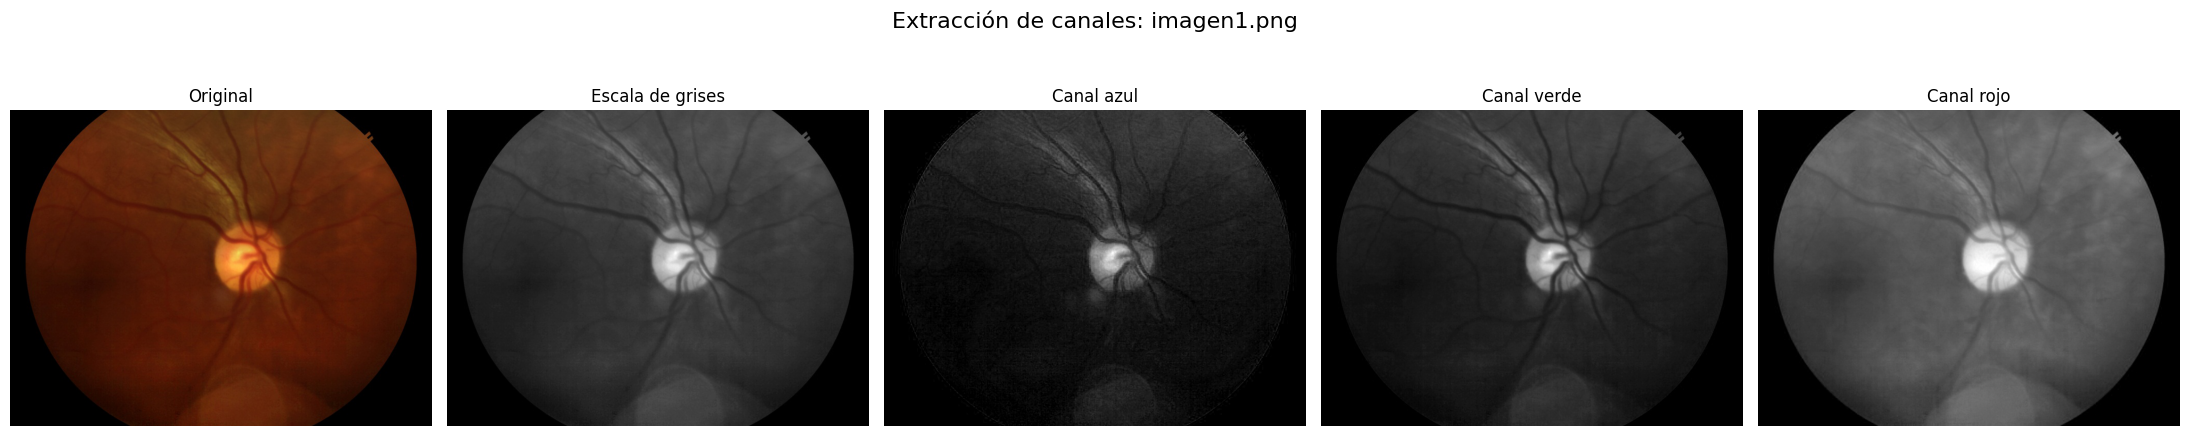

Procesada: imagen1.png


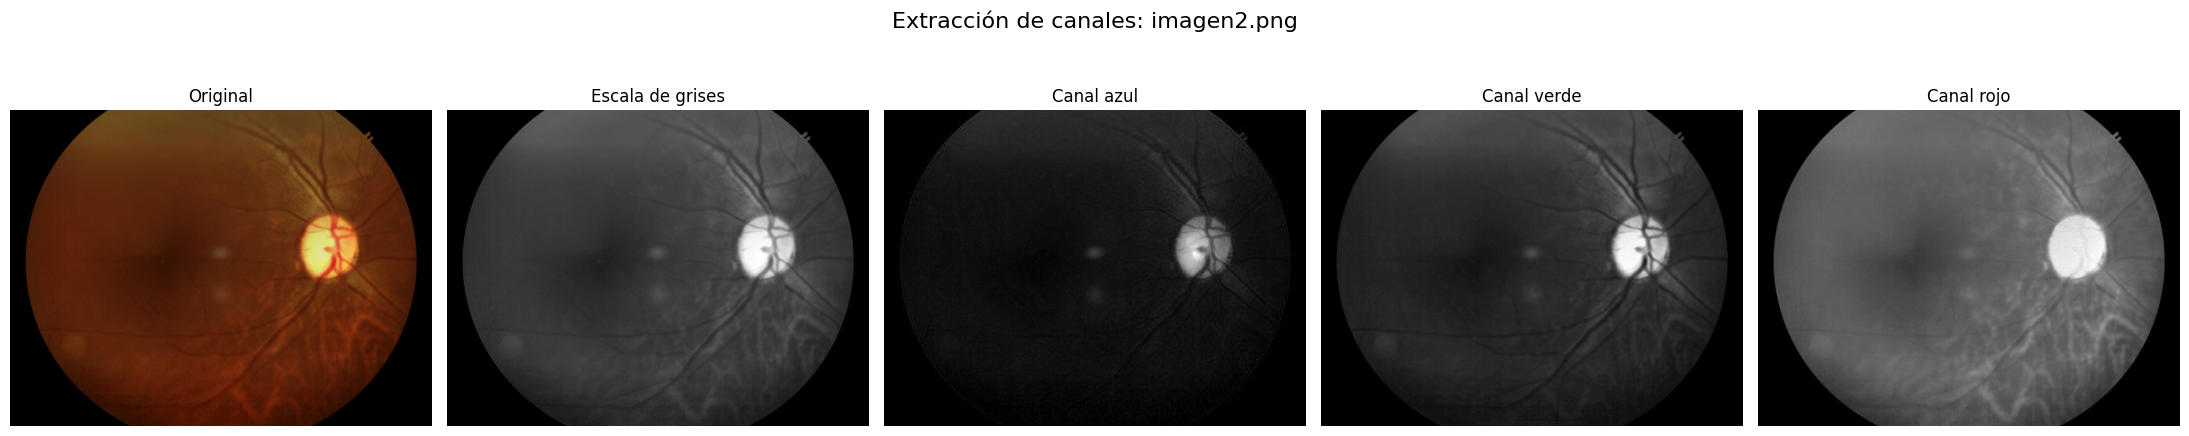

Procesada: imagen2.png


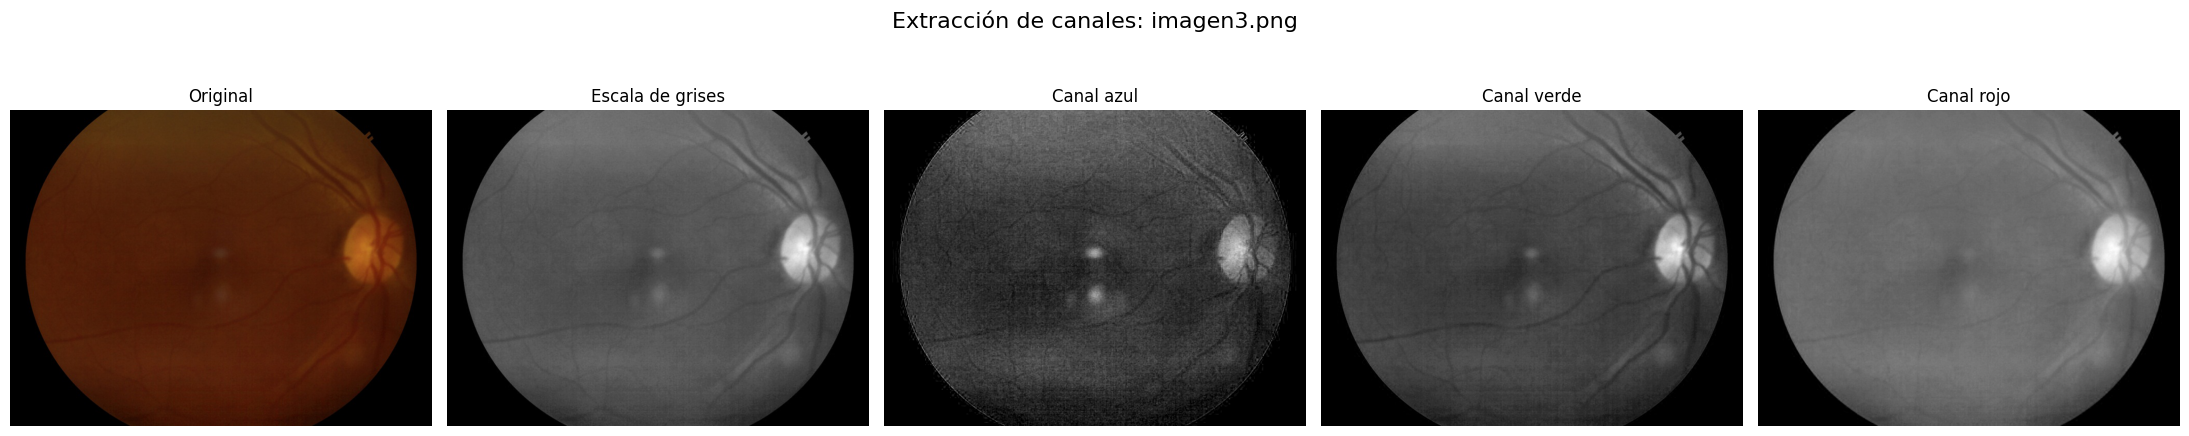

In [ ]:
formatos_validos = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# ciclo for para recorrer todas las imagenes en la carpeta
for archivo_imagen in os.listdir(carpeta_imagenes): # obtiene la lista de todos los archivos
    if archivo_imagen.lower().endswith(formatos_validos): # lower es para que cambie a minusculas
        # endswith es para verificar que sea un formato valido
        ruta_imagen = os.path.join(carpeta_imagenes, archivo_imagen)
        #Se construye la ruta completa de cada imagen para que OpenCV pueda localizarla correctamente dentro de la carpeta

        # Leer imagen en formato BGR, carga la imagen y la guarda como variable (matriz)
        imagen_bgr = cv2.imread(ruta_imagen)

        # Validar lectura 
        #Se valida que la imagen haya sido cargada correctamente.
        # Si la lectura falla, el programa muestra un mensaje y continúa con la siguiente imagen sin detenerse.
        if imagen_bgr is None:
            print(f'No se pudo leer la imagen: {archivo_imagen}')
            continue

        # Convertir a RGB para visualizar correctamente con matplotlib
        # ya que ambas librerías manejan distinto el orden de los canales de color
        imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

        # Convertir a escala de grises
        imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

        # Extraer canales BGR asignando un número a cada color para irse a ese canal
        canal_azul = imagen_bgr[:, :, 0]
        canal_verde = imagen_bgr[:, :, 1]
        canal_rojo = imagen_bgr[:, :, 2]

        # Nombre base del archivo, sin su extensión, para reutilizarlo al guardar las imágenes procesadas con nombres organizados
        nombre_base = os.path.splitext(archivo_imagen)[0]

        # Guardar imágenes por separado, usando cv2.imwrite(), conservando un nombre basado en el archivo original
        cv2.imwrite(os.path.join(carpeta_gris, f'{nombre_base}_gris.png'), imagen_gris)
        cv2.imwrite(os.path.join(carpeta_azul, f'{nombre_base}_azul.png'), canal_azul)
        cv2.imwrite(os.path.join(carpeta_verde, f'{nombre_base}_verde.png'), canal_verde)
        cv2.imwrite(os.path.join(carpeta_rojo, f'{nombre_base}_rojo.png'), canal_rojo)

        # Crear subplots, Se genera una figura con cinco subgráficas en una sola fila para comparar visualmente la imagen original
        # la escala de grises y los tres canales de color
        fig, axes = plt.subplots(1, 5, figsize=(22, 5))
        fig.suptitle(f'Extracción de canales: {archivo_imagen}', fontsize=16) # Pone un título arriba de toda la figura

        # muestra la imagen original en la primera posición
        axes[0].imshow(imagen_rgb)
        axes[0].set_title('Original')
        axes[0].axis('off')

        # muestra imagen en tonos grises en la segunda posición
        axes[1].imshow(imagen_gris, cmap='gray')
        axes[1].set_title('Escala de grises')
        axes[1].axis('off')

        # muestra imagen en tonos azules en la tercera posición
        axes[2].imshow(canal_azul, cmap='gray')
        axes[2].set_title('Canal azul')
        axes[2].axis('off')

        # muestra imagen en tonos verdes en la cuarta posición
        axes[3].imshow(canal_verde, cmap='gray')
        axes[3].set_title('Canal verde')
        axes[3].axis('off')

        # muestra imagen en tonos rojos en la quinta posición
        axes[4].imshow(canal_rojo, cmap='gray')
        axes[4].set_title('Canal rojo')
        axes[4].axis('off')

        # Ajusta automáticamente los espacios entre las subgráficas
        plt.tight_layout()

        # Guardar comparativa
        ruta_comparativa = os.path.join(carpeta_comparativas, f'{nombre_base}_comparativa.png')
        plt.savefig(ruta_comparativa, bbox_inches='tight', dpi=300)
        # La figura comparativa se guarda con buena resolución (300 dpi)
        # y con ajuste de márgenes para obtener una imagen clara y bien presentada

        # Mostrar la figura
        plt.show()
        plt.close(fig)
        # Se cierra la figura después de mostrarla para liberar memoria 
        # y evitar acumulación de ventanas o recursos durante el procesamiento de múltiples imágenes

        print(f'Procesada: {archivo_imagen}')

print('Procesamiento completado.')